### <span style="color:#FFA726">Evaluation</span>

This notebook has three parts:

1. **Pre-Code Notes** — the plan, metrics used, before any code.
2. **Evaluation Code** — computing NDCG@10, Recall@10, and Coverage for both models.
3. **Comparison & Discussion** — baseline vs. MF/ALS results, and next steps (tuning if needed).

### <span style="color:#FFA726">1. Pre-Code Notes</span>

**Goal:** For each user, check whether their held-out `test` item appears in the
model's top-10 recommendations, and how highly ranked it is. Do this for both
Popularity and MF/ALS, then compare.

**Relevance threshold (per our risk-mitigation plan):** our ratings are heavily
skewed toward 5 stars (62.6%), which makes "relevant" hard to define. To deal
with this, we only evaluate on test rows where the held-out rating is **4 or 5**. A test item with a rating below 4 is excluded from evaluation, since it isn't
a meaningful positive example.

**Metrics:**
- **NDCG@10**: rewards the true item appearing near the top of the top-10 list,
  not just being present. Since leave-last-out gives exactly one relevant item
  per user, NDCG@10 for a single user simplifies to `1 / log2(rank + 2)` if the
  item is found at position `rank` (0-indexed), else `0`.
- **Recall@10**: simpler, binary: `1` if the true item is anywhere in the
  top-10, else `0`.
- **Coverage**: the fraction of the whole catalog that ever appears across all
  users' top-10 lists, computed separately for Popularity and MF/ALS.

**Extra analysis:** Instead of filtering
out low-activity users with an arbitrary cutoff, we plot each user's NDCG@10
(MF/ALS) against how many interactions they had in `train`, to see whether
sparsity is actually hurting personalization, without needing to defend a
specific threshold.

**Steps:**
1. Load `test` and the two saved recommendation files.
2. Filter `test` to rows with rating ≥ 4. This is our evaluation set.
3. For each user in the filtered set, compute NDCG@10 and Recall@10 for both
   models.
4. Average across users to get one NDCG@10 and one Recall@10 per model.
5. Compute Coverage per model using the *original* (unfiltered) recommendation
   lists. Coverage is about what the model recommends overall, not tied to the
   relevance filter.
6. Compare the two models side by side.
7. Plot MF/ALS's per-user NDCG@10 against train interaction count.

### <span style="color:#FFA726">2. Evaluation Code</span>

In [3]:
import pandas as pd
import numpy as np

train = pd.read_parquet('datasets/train.parquet')
test = pd.read_parquet('datasets/test.parquet')

popularity_recs = pd.read_parquet('datasets/popularity_recommendations.parquet')
als_recs = pd.read_parquet('datasets/als_recommendations.parquet')

print("test:", len(test))
print("popularity_recs:", len(popularity_recs))
print("als_recs:", len(als_recs))

test: 657203
popularity_recs: 657203
als_recs: 657203


In [4]:
# Relevance threshold: only evaluate on test rows where the held-out rating is 4 or 5
eval_test = test[test['rating'] >= 4].copy()

print("Total test rows:", len(test))
print("Eval test rows (rating >= 4):", len(eval_test))
print("Dropped (rating < 4):", len(test) - len(eval_test))

# user_id -> their single relevant (held-out) item
relevant_item = eval_test.set_index('user_id')['parent_asin']

Total test rows: 657203
Eval test rows (rating >= 4): 525320
Dropped (rating < 4): 131883


In [5]:
def ndcg_recall_at_10(recs_df, relevant_item):
    """
    recs_df: DataFrame with columns ['user_id', 'top10'] (top10 = list of item ids)
    relevant_item: Series indexed by user_id -> their single relevant item

    Returns per-user NDCG@10 and Recall@10, only for users present in relevant_item.
    """
    recs_lookup = recs_df.set_index('user_id')['top10']

    ndcg_scores = {}
    recall_scores = {}

    for user_id, true_item in relevant_item.items():
        if user_id not in recs_lookup.index:
            continue  # user has no recommendations for this model, skip

        top10 = list(recs_lookup.loc[user_id])

        if true_item in top10:
            rank = top10.index(true_item)  # 0-indexed position
            ndcg_scores[user_id] = 1 / np.log2(rank + 2)
            recall_scores[user_id] = 1
        else:
            ndcg_scores[user_id] = 0
            recall_scores[user_id] = 0

    return pd.Series(ndcg_scores), pd.Series(recall_scores)

In [6]:
pop_ndcg, pop_recall = ndcg_recall_at_10(popularity_recs, relevant_item)
als_ndcg, als_recall = ndcg_recall_at_10(als_recs, relevant_item)

print("Popularity — users evaluated:", len(pop_ndcg))
print("Popularity — NDCG@10:", round(pop_ndcg.mean(), 4))
print("Popularity — Recall@10:", round(pop_recall.mean(), 4))

print("\nMF/ALS — users evaluated:", len(als_ndcg))
print("MF/ALS — NDCG@10:", round(als_ndcg.mean(), 4))
print("MF/ALS — Recall@10:", round(als_recall.mean(), 4))

Popularity — users evaluated: 525320
Popularity — NDCG@10: 0.0093
Popularity — Recall@10: 0.0195

MF/ALS — users evaluated: 525320
MF/ALS — NDCG@10: 0.01
MF/ALS — Recall@10: 0.019


##### <span style="color:#FFA726">Coverage</span>

In [7]:
def coverage_at_10(recs_df, catalog_size):
    all_recommended = set()
    for top10 in recs_df['top10']:
        all_recommended.update(top10)
    return len(all_recommended) / catalog_size

catalog_size = train['parent_asin'].nunique()

pop_coverage = coverage_at_10(popularity_recs, catalog_size)
als_coverage = coverage_at_10(als_recs, catalog_size)

print("Catalog size (unique items in train):", catalog_size)
print("Popularity — Coverage:", round(pop_coverage, 4))
print("MF/ALS — Coverage:", round(als_coverage, 4))

Catalog size (unique items in train): 197747
Popularity — Coverage: 0.0001
MF/ALS — Coverage: 0.0019


##### <span style="color:#FFA726">Sanity check</span>

In [8]:
# Sanity check: same users evaluated for both models
assert len(pop_ndcg) == len(als_ndcg), "User count mismatch between models!"
assert set(pop_ndcg.index) == set(als_ndcg.index), "Different users evaluated!"
print("Sanity check passed: both models evaluated on the same", len(pop_ndcg), "users")

Sanity check passed: both models evaluated on the same 525320 users


**Result** 

Popularity's Coverage (0.0001) is very low, as expected.
It recommends the same handful of items to everyone. MF/ALS's Coverage (0.0019)
is about 19x higher, confirming it is recommending a meaningfully wider range
of items across users, i.e. personalization is having a real effect on what
gets recommended, even if it doesn't yet show up as a clear relevance gain.</span>

### <span style="color:#FFA726">3. Comparison & Discussion</span>

In [9]:
results = pd.DataFrame({
    'Model': ['Popularity', 'MF/ALS'],
    'NDCG@10': [pop_ndcg.mean(), als_ndcg.mean()],
    'Recall@10': [pop_recall.mean(), als_recall.mean()],
    'Coverage': [pop_coverage, als_coverage]
})

results

,Model,NDCG@10,Recall@10,Coverage
0,Popularity,0.009342,0.019491,0.000101
1,MF/ALS,0.009994,0.018969,0.001871


<span style="color:#1A237E">**MF/ALS shows a small NDCG@10 improvement over Popularity (0.0093 → 0.0100) but a slight decrease in Recall@10 (0.0195 → 0.0190), so the relevance improvement is marginal and inconsistent — this answers RQ1. For RQ2, Coverage improves substantially (0.0001 → 0.0019, ~19x), shows MF/ALS spreads recommendations across a wider part of the catalog. But this diversity doesn't yet translate into a clear relevance advantage, consistent with the sparse-user limitation identified earlier.</span>

             mean   count
bucket                   
5-9      0.010081  182474
10-19    0.007061   81587
20-49    0.003457   33946
50-99    0.002686    6226
100-199  0.001606    1632
200+     0.001869     535


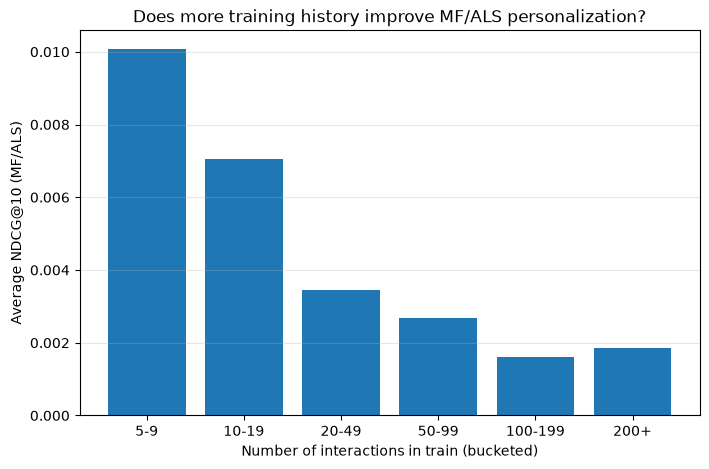

In [10]:
import matplotlib.pyplot as plt

# Per-user train interaction count
train_counts = train.groupby('user_id').size()

# Align with users we actually evaluated for MF/ALS
plot_df = pd.DataFrame({
    'ndcg': als_ndcg,
    'train_interactions': train_counts.reindex(als_ndcg.index)
}).dropna()

# Average NDCG@10 per interaction-count bucket, for a readable trend line
bins = [5, 10, 20, 50, 100, 200, plot_df['train_interactions'].max() + 1]
labels = ['5-9', '10-19', '20-49', '50-99', '100-199', '200+']

plot_df['bucket'] = pd.cut(plot_df['train_interactions'], bins=bins, labels=labels, right=False)

trend = plot_df.groupby('bucket', observed=True)['ndcg'].agg(['mean', 'count'])
print(trend)

plt.figure(figsize=(8, 5))
plt.bar(trend.index.astype(str), trend['mean'])
plt.xlabel('Number of interactions in train (bucketed)')
plt.ylabel('Average NDCG@10 (MF/ALS)')
plt.title('Does more training history improve MF/ALS personalization?')
plt.grid(axis='y', alpha=0.3)
plt.show()

<span style="color:#1A237E">**Contrary to expectation, NDCG@10 decreases as users have more train interactions (0.0101 for 5-9 interactions vs. 0.0016 for 100-199), before ticking up slightly at 200+. This suggests light users may be easier to predict because their ratings align more with globally popular items, while power users have more niche tastes that are harder for ALS to capture even with more data. This complicates the assumption that 'warm' users are simply easier to personalize for.</span>

#### <span style="color:#BA68C8">Saving</span>

In [11]:
results.to_csv('datasets/evaluation_results.csv', index=False)
print("Saved to datasets/evaluation_results.csv")

Saved to datasets/evaluation_results.csv
